use call IV or put only, use "underlying last" column instead of strike distance

In [8]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import scipy
import scipy.optimize
from scipy.interpolate import interp1d
from sklearn.isotonic import IsotonicRegression


# ============================================================
# Optional: make output less noisy
# ============================================================
warnings.filterwarnings('ignore')


# ============================================================
# Config
# ============================================================
FIRST_YEAR = 2010
LAST_YEAR = 2023
PREFIX = "./extracted_data/spx_eod"

FINAL_FILENAME = f"combined_ssvi_mse_{FIRST_YEAR}_to_{LAST_YEAR}_civ20260304_dlt_outliers.json"
COUNTS_CSV = f"daily_point_counts_{FIRST_YEAR}_to_{LAST_YEAR}_civ20260304_dlt_outliers.csv"
COUNTS_JSON = f"daily_point_counts_{FIRST_YEAR}_to_{LAST_YEAR}_civ20260304_dlt_outliers.json"


# ============================================================
# Helpers: SSVI parameterization
# ============================================================
def powerLaw(eta, gamma, theta):
    # theta expected positive
    return eta / (theta**gamma * (1 + theta)**(1 - gamma))

def powerLawConstraint(args):
    rho, eta, gamma = args
    return 2 - eta * (1 + np.abs(rho))

def parameterization(atm_iv, t, rho, k, eta, gamma):
    """
    Returns total variance w(k,t) under SSVI with power-law phi.
    Adds numerical guards to avoid NaNs/infs and sqrt of negative due to floating errors.
    """
    atm_iv = np.asarray(atm_iv, dtype=np.float64)
    t = np.asarray(t, dtype=np.float64)
    k = np.asarray(k, dtype=np.float64)

    theta = (atm_iv**2) * t
    # Guard: theta must be strictly positive for theta**gamma when gamma>0
    # theta = np.maximum(theta, 1e-16)

    phi = powerLaw(eta, gamma, theta)
    # Guard against NaN/inf from extreme params
    # ! excuse
    # phi = np.nan_to_num(phi, nan=0.0, posinf=1e16, neginf=0.0)

    term = (phi * k + rho)**2 + (1 - rho**2)
    # Guard against tiny negative from floating point / NaNs already handled above
    # term = np.nan_to_num(term, nan=0.0, posinf=1e32, neginf=0.0)
    # term = np.maximum(term, 0.0)

    w = (0.5 * theta) * (1 + rho * phi * k + np.sqrt(term))
    # Final guard
    # w = np.nan_to_num(w, nan=1e32, posinf=1e32, neginf=0.0)
    # ! excuse end
    return w

# SSE -> MSE (divide by number of points)
def least_squares_evaluation(args, real, atm_iv, t, k):
    rho, eta, gamma = args
    prediction = parameterization(atm_iv, t, rho, k, eta, gamma)
    err2 = (real - prediction) ** 2
    return float(np.mean(err2))



# ============================================================
# Data processing
# ============================================================
def process_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df.columns = df.columns.str.strip().str.replace(r"[\[\]]", "", regex=True)
    df = df[df["DTE"] != 0].reset_index(drop=True)

    df["QUOTE_DATE"] = df["QUOTE_DATE"].astype(str).str.strip().str.replace(r"[\[\]]", "", regex=True)

    # Keep your original SPOT logic (based on first row)
    df["SPOT"] = df['UNDERLYING_LAST']

    # numeric conversions
    df["STRIKE"] = pd.to_numeric(df["STRIKE"], errors="coerce")
    df["SPOT"] = pd.to_numeric(df["SPOT"], errors="coerce")

    df["LOG_MONEYNESS"] = np.log(df["STRIKE"] / df["SPOT"])
    df["TTM"] = df["DTE"] / 365.0

    # left put, right call
    df["IV"] = df["C_IV"]

    df["IV"] = pd.to_numeric(df["IV"], errors="coerce")
    df["LOG_MONEYNESS"] = pd.to_numeric(df["LOG_MONEYNESS"], errors="coerce")
    df["TTM"] = pd.to_numeric(df["TTM"], errors="coerce")
    df["DTE"] = pd.to_numeric(df["DTE"], errors="coerce")

    df["TTM"] = df["TTM"].round(6)

    # drop invalid rows
    df = df[np.isfinite(df["LOG_MONEYNESS"]) & np.isfinite(df["TTM"]) & np.isfinite(df["IV"])].reset_index(drop=True)

    # ======================================
    # 新增：删除 deep ITM + tiny IV 的异常点
    # 条件：LOG_MONEYNESS < -0.05 且 IV < 0.001
    # ======================================
    mask_drop = (df["LOG_MONEYNESS"] < -0.05) & (df["IV"] < 0.001)
    df = df.loc[~mask_drop].reset_index(drop=True)

    return df


# ============================================================
# SSVI calibration per date
# - returns number of points used in optimization
# ============================================================
def SSVI(date, df, results):
    data = df[((df["QUOTE_DATE"] == date) & (df["TTM"] != 0))].copy()
    if data.empty:
        raise ValueError(f"{date}: no data after filtering TTM != 0")

    # -------- Step 1: per-slice interpolate ATM_IV --------
    slices = data["TTM"].unique()
    atm_iv_list = []

    for x in slices:
        slic = data[data["TTM"] == x][["LOG_MONEYNESS", "IV"]].copy()

        # Clean + dedupe + sort to avoid interp1d divide-by-zero warnings
        slic = slic.dropna()
        slic = slic[np.isfinite(slic["LOG_MONEYNESS"]) & np.isfinite(slic["IV"])]
        slic = slic.groupby("LOG_MONEYNESS", as_index=False)["IV"].mean()
        slic = slic.sort_values("LOG_MONEYNESS")

        if slic["LOG_MONEYNESS"].nunique() < 2:
            continue

        xk = slic["LOG_MONEYNESS"].to_numpy(dtype=float)
        yv = slic["IV"].to_numpy(dtype=float)

        kind = "cubic" if len(slic) >= 4 else "linear"
        interpolation = interp1d(
            xk,
            yv,
            kind=kind,
            fill_value="extrapolate",
            assume_sorted=True
        )

        atm_iv = float(interpolation(0.0))
        atm_iv = float(np.asarray(atm_iv).item())

        if (atm_iv <= 0) or (not np.isfinite(atm_iv)):
            continue

        atm_iv_list.append({"TTM": float(x), "ATM_IV": float(atm_iv)})

    if len(atm_iv_list) < 2:
        raise ValueError(f"{date}: not enough ATM maturities")

    # -------- Step 2: enforce monotone total variance theta(t)=ATM_IV^2 * t --------
    ttms = np.array([p["TTM"] for p in atm_iv_list], dtype=float)
    atm_ivs = np.array([p["ATM_IV"] for p in atm_iv_list], dtype=float)

    idx = np.argsort(ttms)
    ttms = ttms[idx]
    atm_ivs = atm_ivs[idx]

    uniq_t, inv = np.unique(ttms, return_inverse=True)
    if len(uniq_t) != len(ttms):
        iv_sum = np.zeros_like(uniq_t)
        cnt = np.zeros_like(uniq_t)
        for i, g in enumerate(inv):
            iv_sum[g] += atm_ivs[i]
            cnt[g] += 1
        atm_ivs = iv_sum / np.maximum(cnt, 1)
        ttms = uniq_t

    theta_pts = (atm_ivs ** 2) * ttms

    iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
    theta_mono = iso.fit_transform(ttms, theta_pts)

    atm_iv_mono = np.sqrt(np.maximum(theta_mono, 0.0) / ttms)

    atm_iv_dict = {float(t): float(iv) for t, iv in zip(ttms, atm_iv_mono)}
    atm_iv_list = [{"TTM": float(t), "ATM_IV": float(iv)} for t, iv in zip(ttms, atm_iv_mono)]

    data["ATM_IV"] = data["TTM"].map(atm_iv_dict)

    # Keep only points that will actually be used in calibration
    data = data[np.isfinite(data["ATM_IV"]) & (data["ATM_IV"] > 0)].copy()
    if data.empty:
        raise ValueError(f"{date}: no points left after ATM_IV mapping")

    # -------- Step 3: calibration --------
    T = np.array(data["TTM"], dtype=float)
    K = np.array(data["LOG_MONEYNESS"], dtype=float)
    ATM_IV = np.array(data["ATM_IV"], dtype=float)
    target_IV = np.array(data["IV"], dtype=float)

    real = (target_IV ** 2) * T
    n_points_used = int(len(real))

    cons = [{"type": "ineq", "fun": powerLawConstraint}]

    # Provide zero Hessian (reduces trust-constr quasi-Newton noise; does not change minimizer)
    def zero_hess(x, *args):
        return np.zeros((3, 3), dtype=float)

    result = scipy.optimize.minimize(
        least_squares_evaluation,
        x0=[-0.1, 0.4, 1/4],
        args=(real, ATM_IV, T, K),
        bounds=[(-0.99, 0.99), (1e-8, 100000.0), (0, 0.5)],
        method="trust-constr",
        constraints=cons,
        hess=zero_hess
    )

    rho, eta, gamma = result.x

    mse = float(result.fun)                 # already averaged by n_points
    sse = float(mse * n_points_used)        # optional

    results.append({
        "date": str(date),
        "rho": float(rho),
        "eta": float(eta),
        "gamma": float(gamma),
        "mse": mse,                 # ✅ error / n_points
        "sse": sse,                 # optional diagnostic
        "n_points": n_points_used,  # ✅ points used that day
        "atm_iv_list": atm_iv_list
    })

    return n_points_used


# ============================================================
# Main loop
# ============================================================
def main():
    all_results = []
    daily_counts = {}  # date -> n_points_used

    for year in range(FIRST_YEAR, LAST_YEAR + 1):
        year_results = []

        for month in range(1, 13):
            filename = f"{PREFIX}_{year}{month:02d}.txt"
            if not os.path.exists(filename):
                continue

            try:
                df = pd.read_csv(filename, on_bad_lines="skip", low_memory=False)
            except Exception:
                continue

            cleanDf = process_dataframe(df)
            cleanDf = cleanDf[["QUOTE_DATE", "TTM", "DTE", "LOG_MONEYNESS", "IV"]]

            dates = cleanDf["QUOTE_DATE"].unique()

            for oneDate in dates:
                try:
                    n = SSVI(oneDate, cleanDf, year_results)
                    daily_counts[str(oneDate)] = int(n)
                except Exception as e:
                    print(f"{oneDate} calibration failed: {e}")
                    continue

        with open(f"ssvi_results_mse_{year}.json", "w") as f:
            json.dump(year_results, f, indent=2)

        print(f"Results for year {year} have been saved")
        all_results.extend(year_results)

    with open(FINAL_FILENAME, "w") as f:
        json.dump(all_results, f, indent=2)

    counts_df = pd.DataFrame(
        [{"date": d, "n_points": n} for d, n in daily_counts.items()]
    ).sort_values("date")

    counts_df.to_csv(COUNTS_CSV, index=False)
    with open(COUNTS_JSON, "w") as f:
        json.dump(daily_counts, f, indent=2)

    print(f"Saved daily counts to: {COUNTS_CSV} and {COUNTS_JSON}")
    print(f"Saved combined calibrated params to: {FINAL_FILENAME}")


if __name__ == "__main__":
    main()

Results for year 2010 have been saved
Results for year 2011 have been saved
Results for year 2012 have been saved
Results for year 2013 have been saved
Results for year 2014 have been saved
Results for year 2015 have been saved
Results for year 2016 have been saved
Results for year 2017 have been saved
Results for year 2018 have been saved
Results for year 2019 have been saved
Results for year 2020 have been saved
Results for year 2021 have been saved
Results for year 2022 have been saved
Results for year 2023 have been saved
Saved daily counts to: daily_point_counts_2010_to_2023_civ20260304_dlt_outliers.csv and daily_point_counts_2010_to_2023_civ20260304_dlt_outliers.json
Saved combined calibrated params to: combined_ssvi_mse_2010_to_2023_civ20260304_dlt_outliers.json


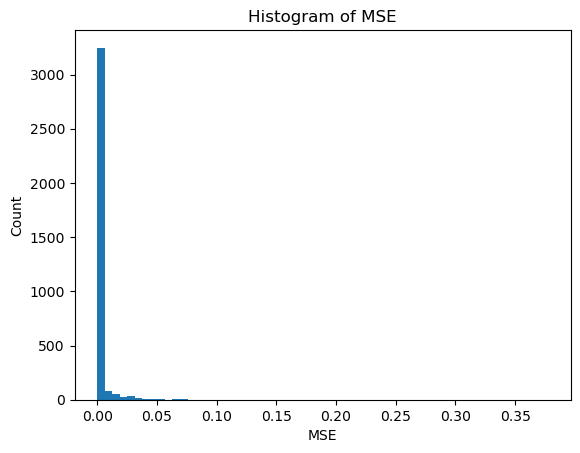


MSE quantiles:
0.00    0.000002
0.01    0.000003
0.05    0.000004
0.10    0.000006
0.25    0.000011
0.50    0.000040
0.75    0.000289
0.90    0.003363
0.95    0.011085
0.99    0.043228
1.00    0.377681

Top 3% worst MSE (count=105), sorted small -> large:
      date      MSE        SSE  n_points
2022-09-21 0.021819 171.302498      7851
2016-06-14 0.021857  54.993101      2516
2019-05-17 0.022163 109.418303      4937
2020-06-12 0.022252 141.257324      6348
2019-05-07 0.022358  92.493614      4137
2015-12-16 0.022389  49.458258      2209
2014-09-17 0.022667  33.751822      1489
2014-12-12 0.023049  55.364624      2402
2021-03-05 0.023257 148.403926      6381
2019-05-08 0.023351 104.262089      4465
2013-06-18 0.023670  20.853589       881
2015-01-13 0.023671  51.199428      2163
2023-02-28 0.023917 176.199451      7367
2021-02-01 0.024142 160.542204      6650
2020-10-06 0.024897 153.611964      6170
2010-03-17 0.025138  13.398774       533
2016-06-13 0.025562  60.376588      2362
2011-

In [9]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== 1) 读取 JSON ======
JSON_PATH = "combined_ssvi_mse_2010_to_2023_civ20260304_dlt_outliers.json"  # <- 改成你的路径

with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# ====== 2) 字段兼容（mse/sse/n_points 可能叫 error 等）======
def pick_col(candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

col_date = pick_col(["date", "DATE", "QUOTE_DATE"])
col_mse  = pick_col(["mse", "MSE", "error", "ERROR"])      # 你当前保存的是 "mse"
col_sse  = pick_col(["sse", "SSE"])
col_n    = pick_col(["n_points", "N_POINTS", "n", "N"])

if col_date is None or col_mse is None:
    raise ValueError(f"Missing required columns. Found columns: {list(df.columns)}")

# 保证数值列是 float/int
df[col_mse] = pd.to_numeric(df[col_mse], errors="coerce")
if col_sse is not None:
    df[col_sse] = pd.to_numeric(df[col_sse], errors="coerce")
if col_n is not None:
    df[col_n] = pd.to_numeric(df[col_n], errors="coerce")

df = df.dropna(subset=[col_mse]).copy()

# 如果没有 SSE 但有 MSE*n_points，可补一个
if col_sse is None and col_n is not None:
    df["sse"] = df[col_mse] * df[col_n]
    col_sse = "sse"

# ====== 3) 画 MSE Histogram ======
plt.figure()
plt.hist(df[col_mse].to_numpy(), bins=60)
plt.title("Histogram of MSE")
plt.xlabel("MSE")
plt.ylabel("Count")
plt.show()

# ====== 4) 输出分位数 ======
qs = [0.00, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]
quantiles = df[col_mse].quantile(qs)
print("\nMSE quantiles:")
print(quantiles.to_string())

# ====== 5) 取误差最大的 3% 并按 MSE 从小到大显示 ======
threshold = df[col_mse].quantile(0.97)     # top 3% -> >= 97th percentile
tail = df[df[col_mse] >= threshold].copy()
tail = tail.sort_values(col_mse, ascending=True)

# 只输出需要的列
out_cols = [col_date, col_mse]
if col_sse is not None:
    out_cols.append(col_sse)
if col_n is not None:
    out_cols.append(col_n)

# 更好看一点：重命名输出列标题
rename_map = {col_date: "date", col_mse: "MSE"}
if col_sse is not None: rename_map[col_sse] = "SSE"
if col_n is not None:   rename_map[col_n] = "n_points"

tail_show = tail[out_cols].rename(columns=rename_map)

print(f"\nTop 3% worst MSE (count={len(tail_show)}), sorted small -> large:")
print(tail_show.to_string(index=False))
print(f"\n97th percentile threshold MSE = {threshold:.10g}")

✅ Loaded MAT. Using surface key = 'surfaces' with shape (3499, 1, 28, 28)
✅ Surfaces standardized to shape (N,nT,nK) = (3499,28,28)


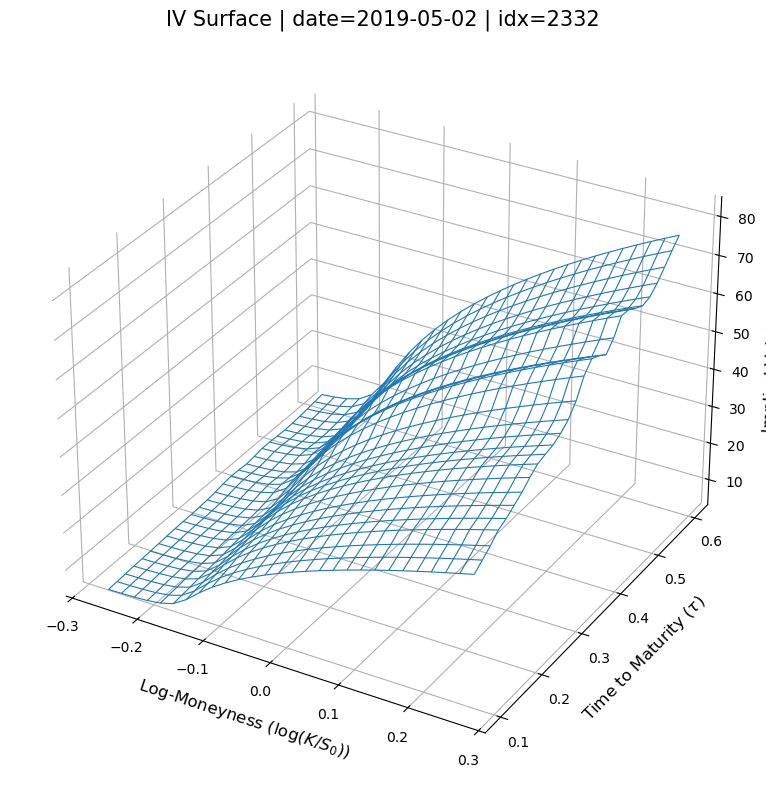

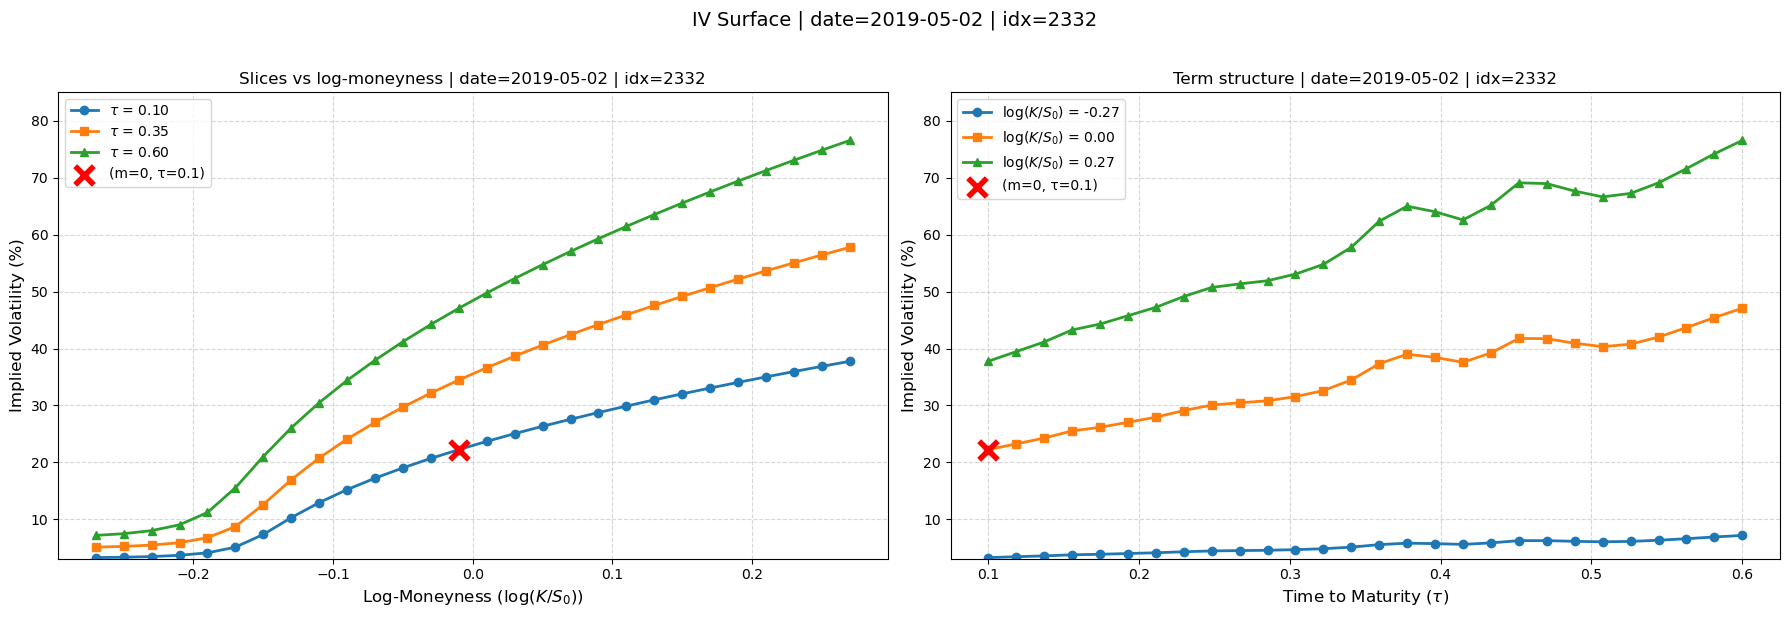

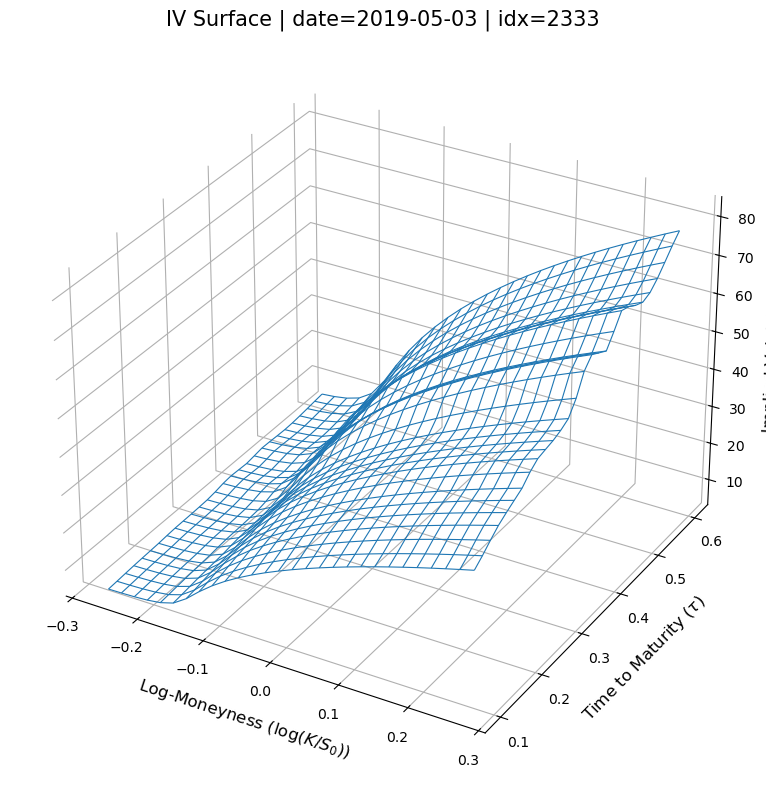

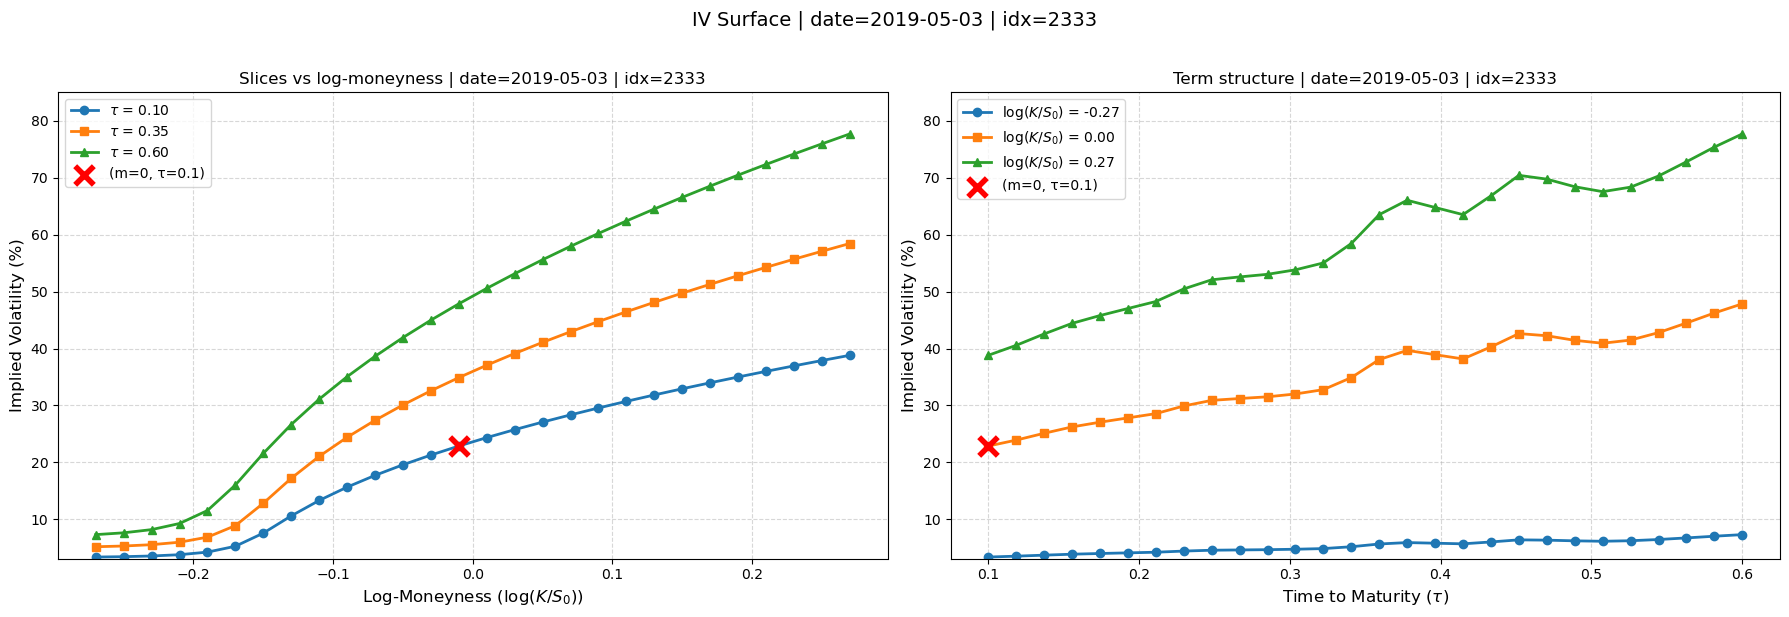

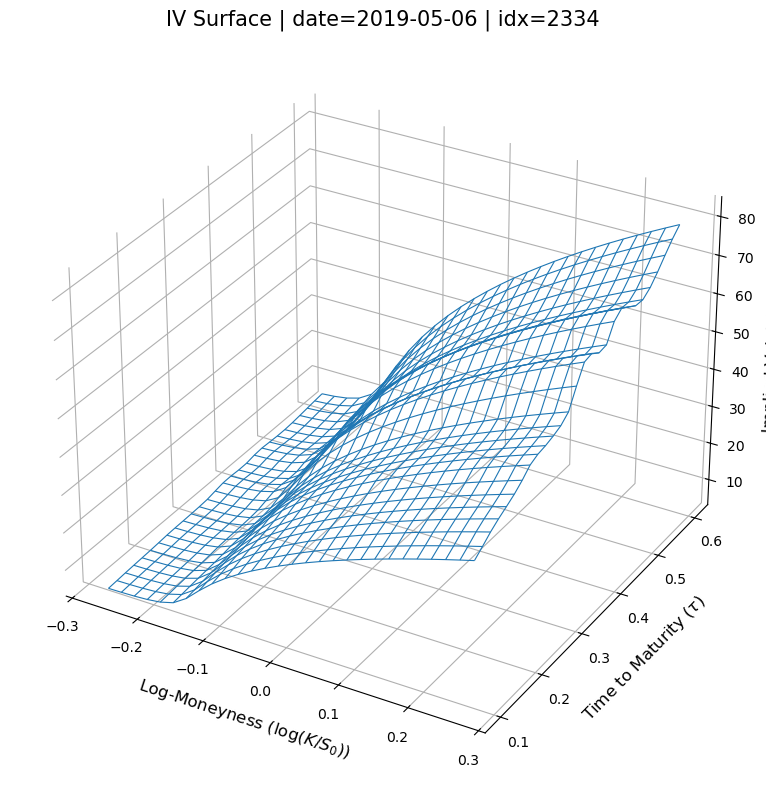

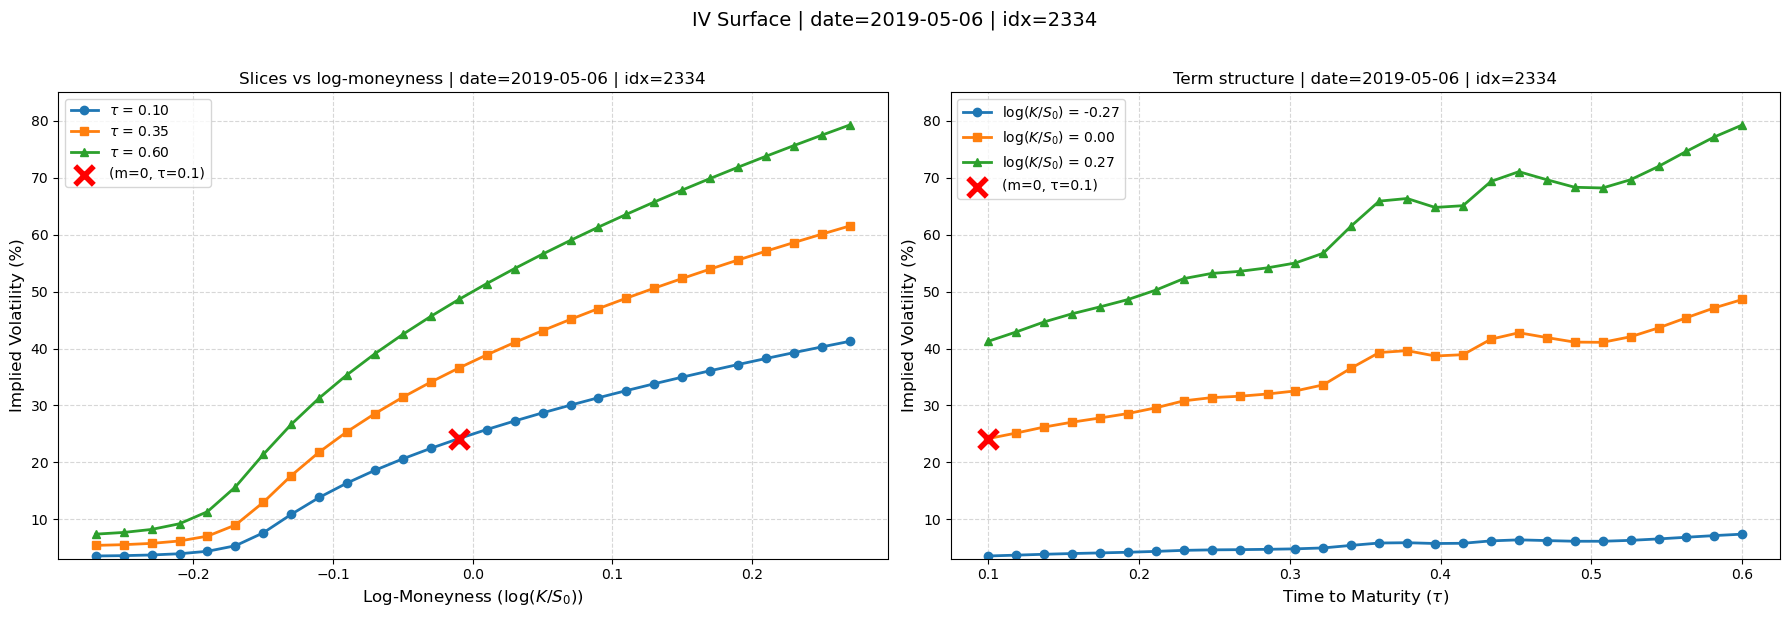

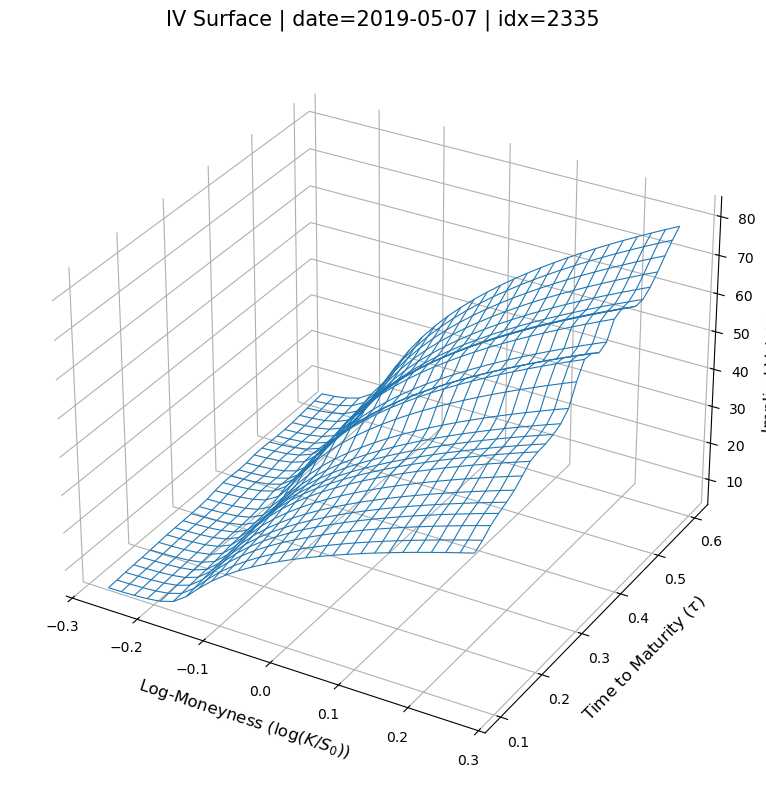

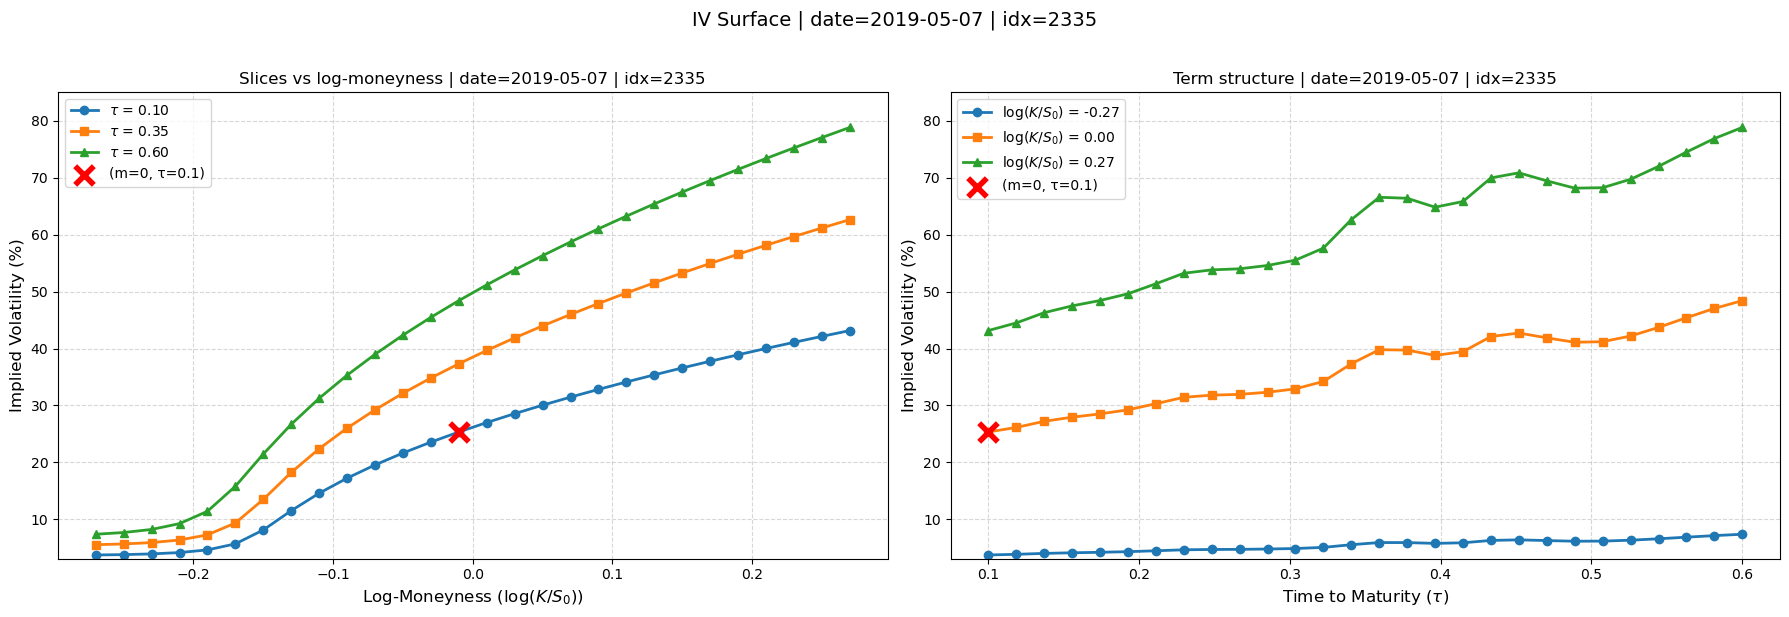

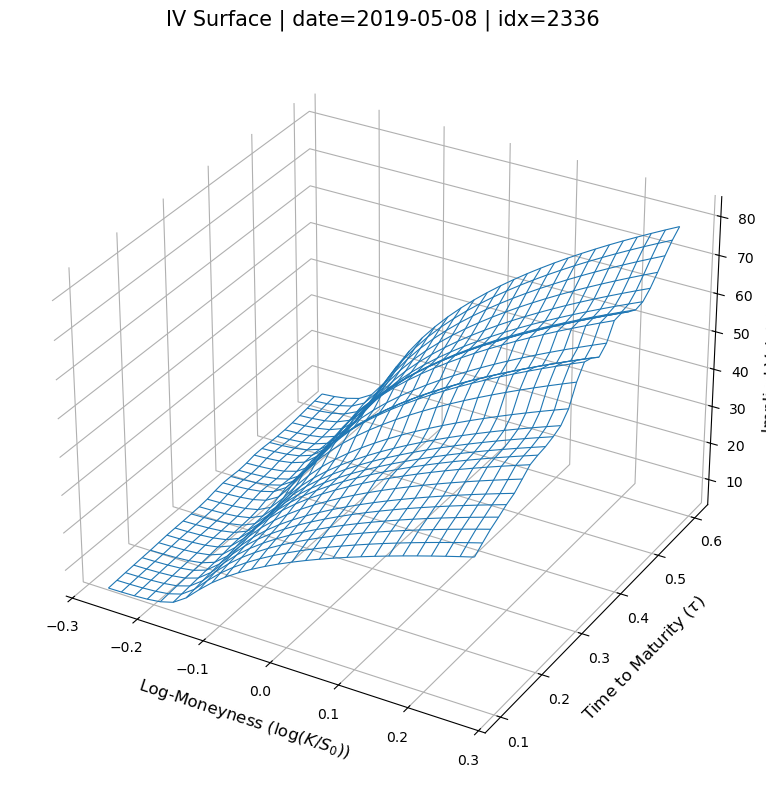

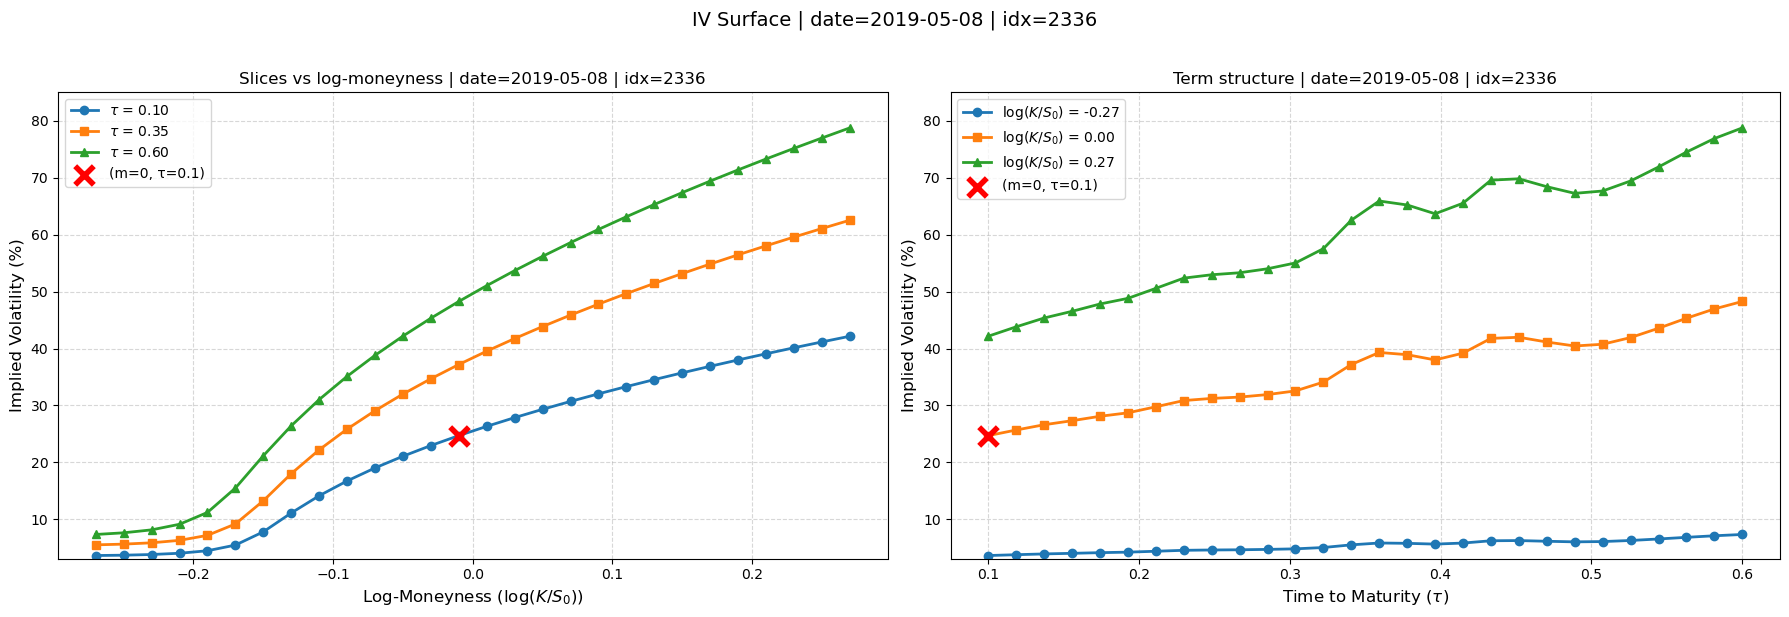

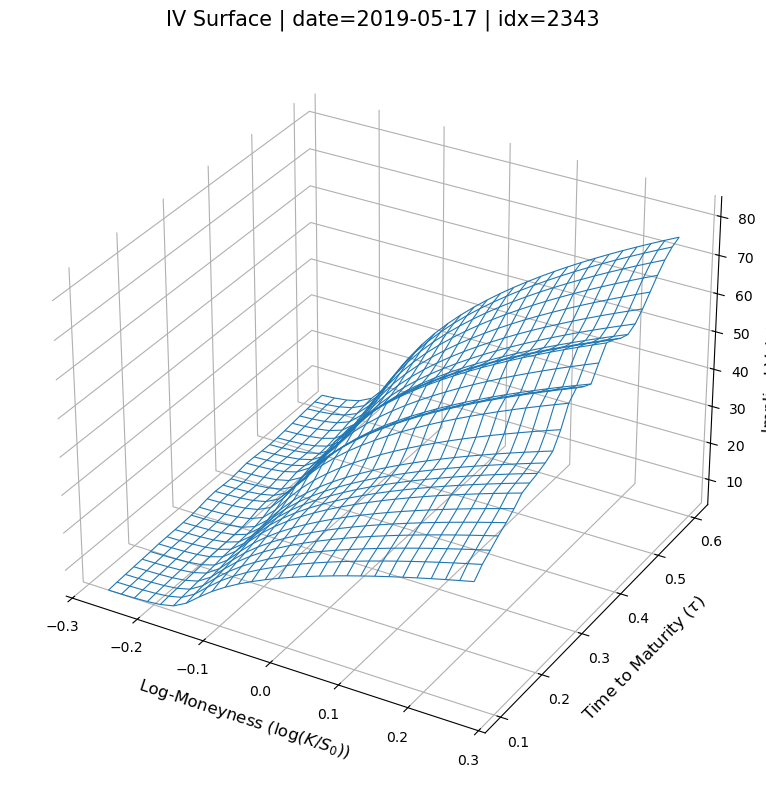

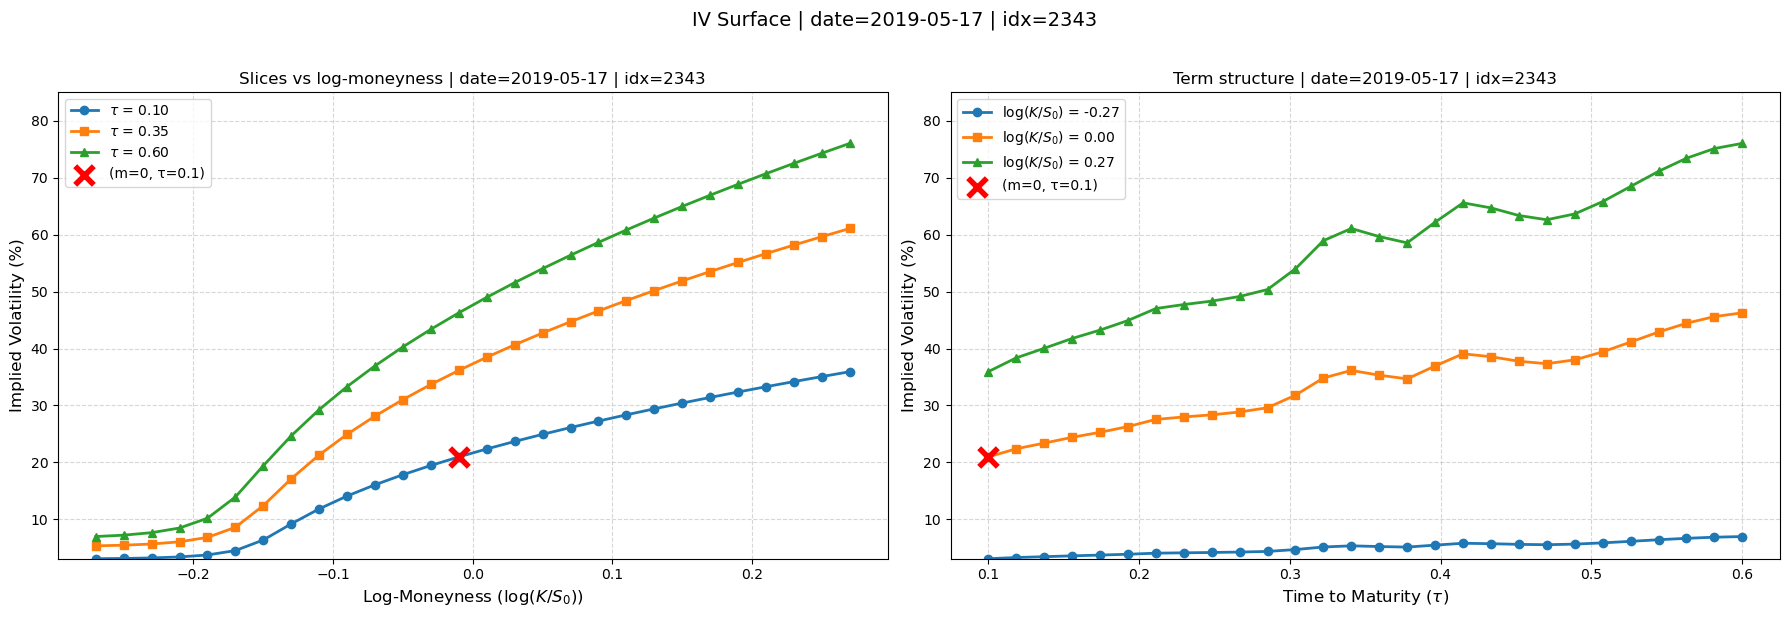

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# ============================================================
# 0) 配置：文件名 + 要画的日期/Index
# ============================================================
MAT_PATH = "ssvi_surfaces_mse_20260225_2010_to_2023_increasing.mat"

# 你给的要画的日期与 index（来自 JSON dataframe 的 index）
TARGETS = [
    ("2019-05-02", 2332),
    ("2019-05-03", 2333),
    ("2019-05-06", 2334),
    ("2019-05-07", 2335),
    ("2019-05-08", 2336),
    ("2019-05-17", 2343),
]

# 你希望的坐标范围（和你前面一致）
T_MIN, T_MAX = 0.1, 0.6
K_MIN, K_MAX = -0.27, 0.27

# 每个 2D 图里取 3 条线（同你前面）
N_SLICES = 3


# ============================================================
# 1) 读取 .mat，并自动找到 surface 数组
# ============================================================
mat = loadmat(MAT_PATH)

# 去掉 MATLAB 的系统字段
keys = [k for k in mat.keys() if not k.startswith("__")]

def find_surface_array(mat_dict):
    """
    尝试从 .mat 里找到 implied vol surface 数据。
    返回 (surfaces_array, key_name)。
    """
    # 常见命名候选（你可以按实际情况再加）
    candidates = [
        "impliedVolsurfaces", "implied_vol_surfaces", "iv_surfaces",
        "surfaces", "surface", "data_SPX_test", "data_SPX", "X", "Y"
    ]
    for name in candidates:
        if name in mat_dict:
            arr = mat_dict[name]
            if isinstance(arr, np.ndarray) and arr.size > 0:
                return arr, name

    # 如果候选都没找到，就从所有 key 里找一个“像 surface”的 ndarray
    # 优先挑 ndim>=3 且不是很小的数组
    best = None
    best_name = None
    for name in keys:
        arr = mat_dict[name]
        if isinstance(arr, np.ndarray) and arr.size > 0 and arr.ndim >= 3:
            # 过滤掉明显不是 surface 的（例如 1xN 的向量）
            best = arr
            best_name = name
            break

    return best, best_name

surfaces_raw, surfaces_key = find_surface_array(mat)

if surfaces_raw is None:
    print("❌ 没有在 .mat 里自动找到 surface 数组。可用 keys：")
    print(keys)
    raise ValueError("Please set the correct surface variable name manually.")

print(f"✅ Loaded MAT. Using surface key = '{surfaces_key}' with shape {surfaces_raw.shape}")

# 统一成 shape = (N, nT, nK)
surfaces = np.array(surfaces_raw)

# 常见情况：MATLAB 保存成 (nT, nK, N) 或 (N, nT, nK) 或 (N, 1, nT, nK)
# 下面做个鲁棒 squeeze + 转换
surfaces = np.squeeze(surfaces)

if surfaces.ndim == 3:
    # (N,nT,nK) 或 (nT,nK,N)
    # 如果第一维很小而第三维很大，可能是 (nT,nK,N)
    if surfaces.shape[0] in (28, 32, 64, 100, 280) and surfaces.shape[2] > 500:
        # assume (nT,nK,N) -> (N,nT,nK)
        surfaces = np.transpose(surfaces, (2, 0, 1))
elif surfaces.ndim == 4:
    # (N,1,nT,nK) 或 (1,N,nT,nK) 等
    surfaces = np.squeeze(surfaces)
    if surfaces.ndim == 3 and surfaces.shape[0] in (28, 32, 64, 100, 280) and surfaces.shape[2] > 500:
        surfaces = np.transpose(surfaces, (2, 0, 1))

if surfaces.ndim != 3:
    raise ValueError(f"Surface array must be 3D after squeezing. Got shape: {surfaces.shape}")

N, nT, nK = surfaces.shape
print(f"✅ Surfaces standardized to shape (N,nT,nK) = ({N},{nT},{nK})")

# 全局 y 轴范围（全数据集统一）
min_lim = float(np.nanmin(surfaces))
max_lim = float(np.nanmax(surfaces))


# ============================================================
# 2) 构造网格（长度必须和 surface 的 nT/nK 匹配）
# ============================================================
T_values = np.linspace(T_MIN, T_MAX, nT)
log_K = np.linspace(K_MIN, K_MAX, nK)
log_K2, T_values2 = np.meshgrid(log_K, T_values)

T_sampled = np.linspace(T_MIN, T_MAX, N_SLICES)
log_K_sampled = np.linspace(K_MIN, K_MAX, N_SLICES)

m0_idx = int(np.argmin(np.abs(log_K - 0.0)))
tau01_idx = int(np.argmin(np.abs(T_values - 0.1)))


# ============================================================
# 3) 画图函数：3D + 2D slices
# ============================================================
def plot_one_surface(idx, date_str):
    if idx < 0 or idx >= N:
        print(f"⚠️ idx={idx} out of range (0..{N-1}), skip.")
        return

    surface = surfaces[idx]  # shape (nT, nK)
    surface_np = np.asarray(surface, dtype=float) * 100.0  # 转成百分比显示

    # ===== 3D wireframe =====
    fig_3d = plt.figure(figsize=(10, 8))
    ax3d = fig_3d.add_subplot(111, projection="3d")

    ax3d.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax3d.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
    ax3d.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

    ax3d.plot_wireframe(
        log_K2, T_values2, surface_np,
        rstride=1, cstride=1,
        linewidth=0.8
    )

    ax3d.set_title(f"IV Surface | date={date_str} | idx={idx}", fontsize=15)
    ax3d.set_xlabel(r'Log-Moneyness ($\log(K/S_0)$)', fontsize=12, labelpad=8)
    ax3d.set_ylabel(r'Time to Maturity ($\tau$)', fontsize=12, labelpad=8)
    ax3d.set_zlabel('Implied Volatility (%)', fontsize=12, labelpad=5)
    ax3d.set_zlim(min_lim * 100, max_lim * 100)
    plt.tight_layout()
    plt.show()

    # ===== 2D slices =====
    fig_2d, axs_2d = plt.subplots(1, 2, figsize=(18, 6))
    markers = ['o', 's', '^']

    # 左：固定 T，看 log_K
    ax_left = axs_2d[0]
    ax_left.grid(True, linestyle='--', alpha=0.5)
    for i, t in enumerate(T_sampled):
        t_idx = int(np.argmin(np.abs(T_values - t)))
        ax_left.plot(
            log_K, surface_np[t_idx, :],
            linewidth=2,
            marker=markers[i],
            markersize=6,
            label=fr"$\tau$ = {t:.2f}"
        )

    ax_left.scatter(
        log_K[m0_idx],
        surface_np[tau01_idx, m0_idx],
        color='red', s=180, zorder=10,
        marker='x', linewidths=4,
        label='(m=0, τ=0.1)'
    )

    ax_left.set_xlabel(r'Log-Moneyness ($\log(K/S_0)$)', fontsize=12)
    ax_left.set_ylabel('Implied Volatility (%)', fontsize=12)
    ax_left.set_title(f"Slices vs log-moneyness | date={date_str} | idx={idx}", fontsize=12)
    ax_left.set_ylim(min_lim * 100, max_lim * 100)
    ax_left.legend(fontsize=10, loc='best')

    # 右：固定 log_K，看 T
    ax_right = axs_2d[1]
    ax_right.grid(True, linestyle='--', alpha=0.5)
    for i, k in enumerate(log_K_sampled):
        k_idx = int(np.argmin(np.abs(log_K - k)))
        ax_right.plot(
            T_values, surface_np[:, k_idx],
            linewidth=2,
            marker=markers[i],
            markersize=6,
            label=fr"$\log(K/S_0)$ = {k:.2f}"
        )

    ax_right.scatter(
        T_values[tau01_idx],
        surface_np[tau01_idx, m0_idx],
        color='red', s=180, zorder=10,
        marker='x', linewidths=4,
        label='(m=0, τ=0.1)'
    )

    ax_right.set_xlabel(r'Time to Maturity ($\tau$)', fontsize=12)
    ax_right.set_ylabel('Implied Volatility (%)', fontsize=12)
    ax_right.set_title(f"Term structure | date={date_str} | idx={idx}", fontsize=12)
    ax_right.set_ylim(min_lim * 100, max_lim * 100)
    ax_right.legend(fontsize=10, loc='best')

    fig_2d.suptitle(f"IV Surface | date={date_str} | idx={idx}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# ============================================================
# 4) 逐个画你指定的日期/idx
# ============================================================
for date_str, idx in TARGETS:
    plot_one_surface(idx=idx, date_str=date_str)